In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/petershmorhun/Documents/GitHub/summer_milestone_2/capstone_file/punt_analytics/full_collision_dataset.csv')

/var/folders/4k/nl2zz_ln4d55dcscl_vvjglh0000gn/T/ipykernel_69420/3033090908.py:1: DtypeWarning: Columns (34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/petershmorhun/Documents/GitHub/summer_milestone_2/capstone_file/punt_analytics/full_collision_dataset.csv')


In [3]:
df.head()

,min_distance,distance_at_start,distance_at_end,avg_distance,time_to_closest_approach,max_relative_speed,avg_relative_speed,relative_speed_at_closest,collision_angle,p1_orientation_at_collision,...,gamekey,playid,injured_player,partner_player,impact_type,player_activity,partner_activity,friendly_fire,is_injury,collision_intensity
0,0.830243,55.032141,14.018631,28.302337,15.8,14.119568,3.188342,11.385286,-91.380383,147.539993,...,29,538,31023.0,31941.0,Helmet-to-body,Tackling,Tackled,No,1,0.155704
1,0.317649,17.614100,4.200430,12.388854,12.8,7.597745,3.003402,6.844692,-118.178774,265.940002,...,144,2342,32410.0,23259.0,Helmet-to-body,Blocking,Blocked,No,1,0.186616
2,0.421546,13.157938,3.814251,17.106059,25.3,9.948990,2.790632,0.111793,67.693303,83.870003,...,149,3663,28128.0,29629.0,Helmet-to-body,Blocking,Blocked,No,1,0.195687
3,0.344385,49.928608,0.344385,36.786561,17.8,15.770312,3.859137,2.517935,-64.178810,94.260002,...,189,3509,27595.0,31950.0,Helmet-to-helmet,Tackled,Tackling,No,1,0.364046
4,0.541202,4.128255,2.009976,5.784810,19.5,8.200610,1.534932,1.229842,62.487998,64.940002,...,231,1976,32214.0,32807.0,Helmet-to-helmet,Blocked,Blocked,Yes,1,0.131198


In [4]:
injuries = df.loc[df['is_injury'] == 1]
print(len(injuries))

# sample 100x non-injury rows
n = (10 * len(injuries))
non_injuries = df.loc[df['is_injury'] == 0].sample(n=n, random_state=42)

28


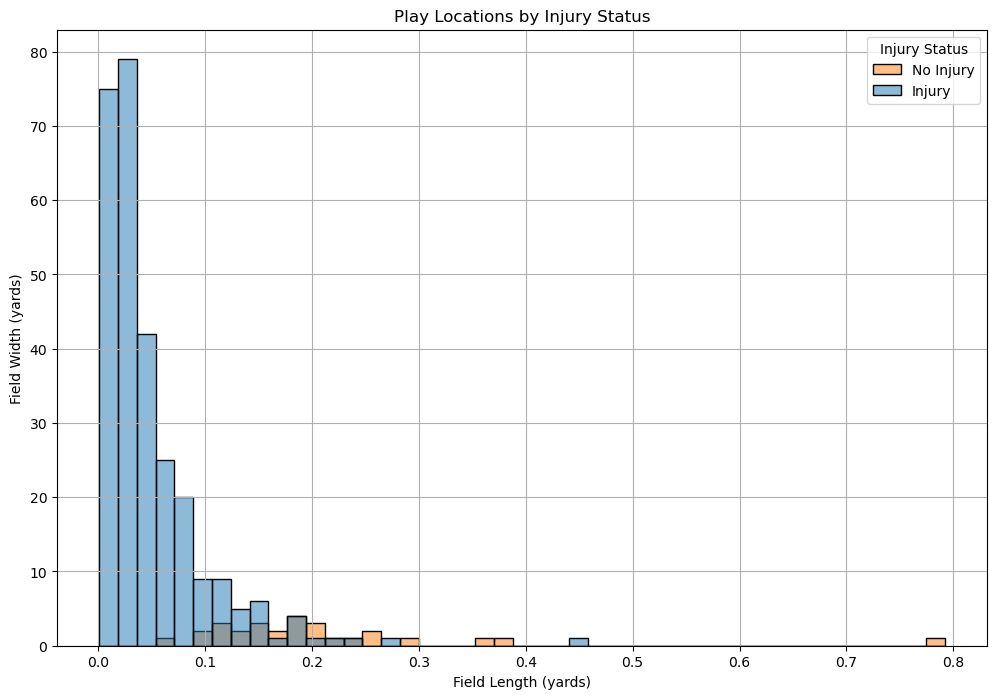

In [5]:
# create summary visualizations of data for injury and non-injury plays
injury_df = pd.concat([injuries, non_injuries])
plt.figure(figsize=(12, 8))
sns.histplot(data=injury_df, x='collision_intensity', hue='is_injury', alpha=0.5)
plt.title('Play Locations by Injury Status')
plt.xlabel('Field Length (yards)')
plt.ylabel('Field Width (yards)')
plt.legend(title='Injury Status', labels=['No Injury', 'Injury'])
plt.grid(True)
plt.show()

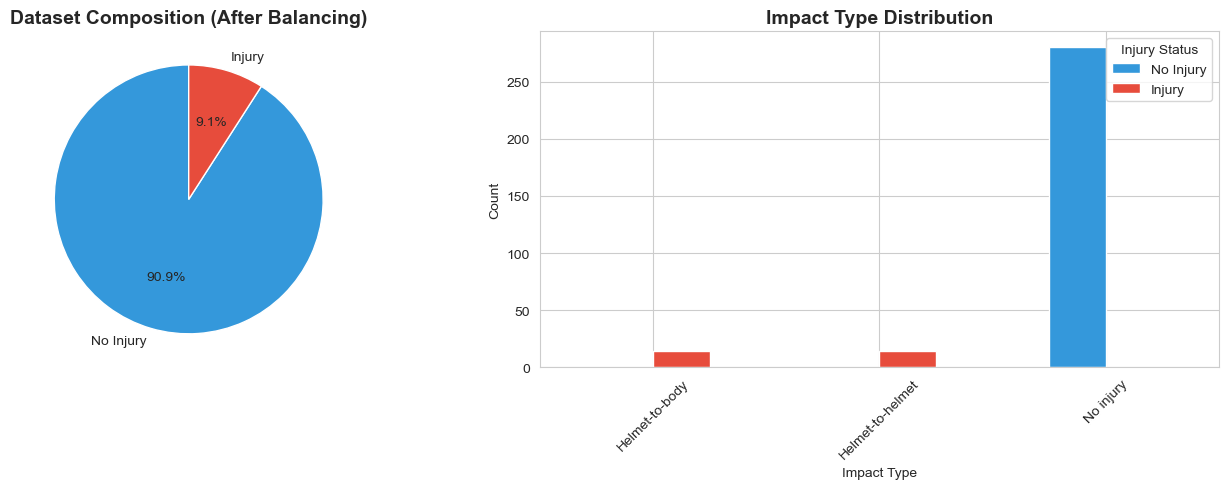

In [6]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Dataset Composition - Injury vs Non-Injury
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
injury_counts = injury_df['is_injury'].value_counts()
axes[0].pie(injury_counts.values, labels=['No Injury', 'Injury'], autopct='%1.1f%%', 
            colors=['#3498db', '#e74c3c'], startangle=90)
axes[0].set_title('Dataset Composition (After Balancing)', fontsize=14, fontweight='bold')

# Impact type distribution by injury status
impact_crosstab = pd.crosstab(injury_df['impact_type'], injury_df['is_injury'])
impact_crosstab.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Impact Type Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Impact Type')
axes[1].set_ylabel('Count')
axes[1].legend(['No Injury', 'Injury'], title='Injury Status')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('dataset_composition.png', dpi=300, bbox_inches='tight')
plt.show()

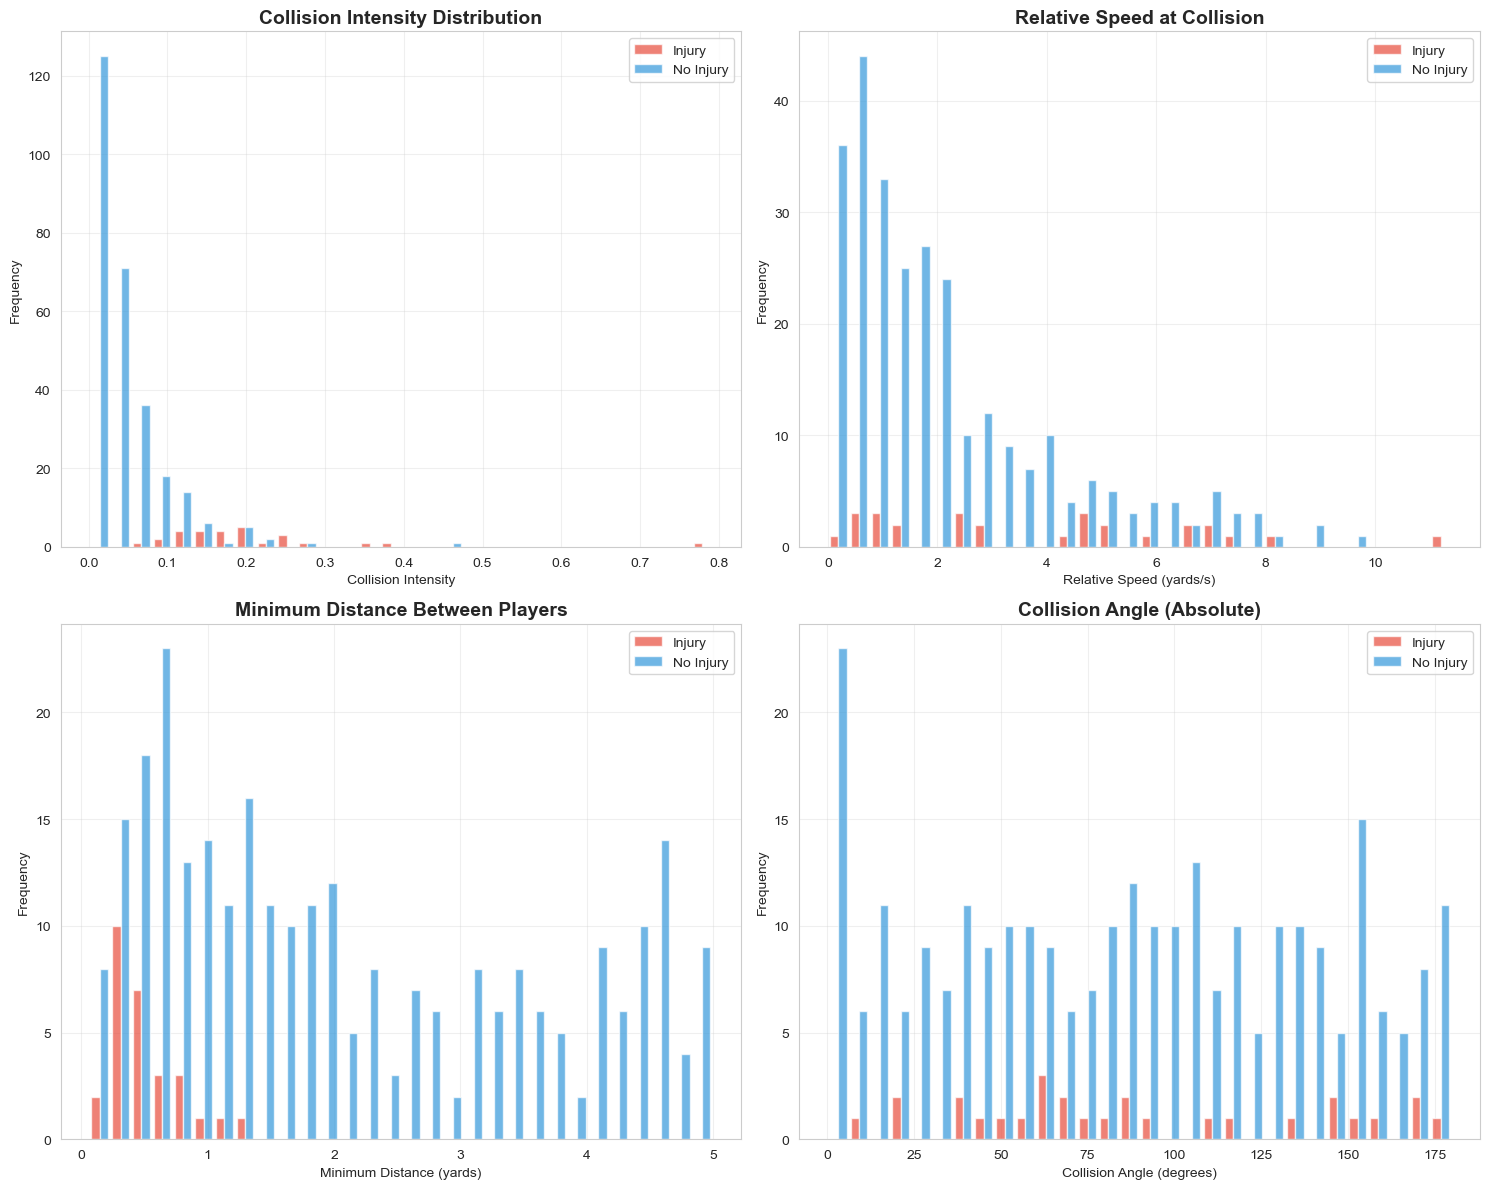

In [7]:
# 2. Key Collision Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Collision Intensity
axes[0, 0].hist([injuries['collision_intensity'], non_injuries['collision_intensity']], 
                bins=30, label=['Injury', 'No Injury'], color=['#e74c3c', '#3498db'], alpha=0.7)
axes[0, 0].set_title('Collision Intensity Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Collision Intensity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Relative Speed at Closest Approach
axes[0, 1].hist([injuries['relative_speed_at_closest'], non_injuries['relative_speed_at_closest']], 
                bins=30, label=['Injury', 'No Injury'], color=['#e74c3c', '#3498db'], alpha=0.7)
axes[0, 1].set_title('Relative Speed at Collision', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Relative Speed (yards/s)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Minimum Distance
axes[1, 0].hist([injuries['min_distance'], non_injuries['min_distance']], 
                bins=30, label=['Injury', 'No Injury'], color=['#e74c3c', '#3498db'], alpha=0.7)
axes[1, 0].set_title('Minimum Distance Between Players', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Minimum Distance (yards)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Collision Angle (absolute value)
axes[1, 1].hist([np.abs(injuries['collision_angle']), np.abs(non_injuries['collision_angle'])], 
                bins=30, label=['Injury', 'No Injury'], color=['#e74c3c', '#3498db'], alpha=0.7)
axes[1, 1].set_title('Collision Angle (Absolute)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Collision Angle (degrees)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('collision_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

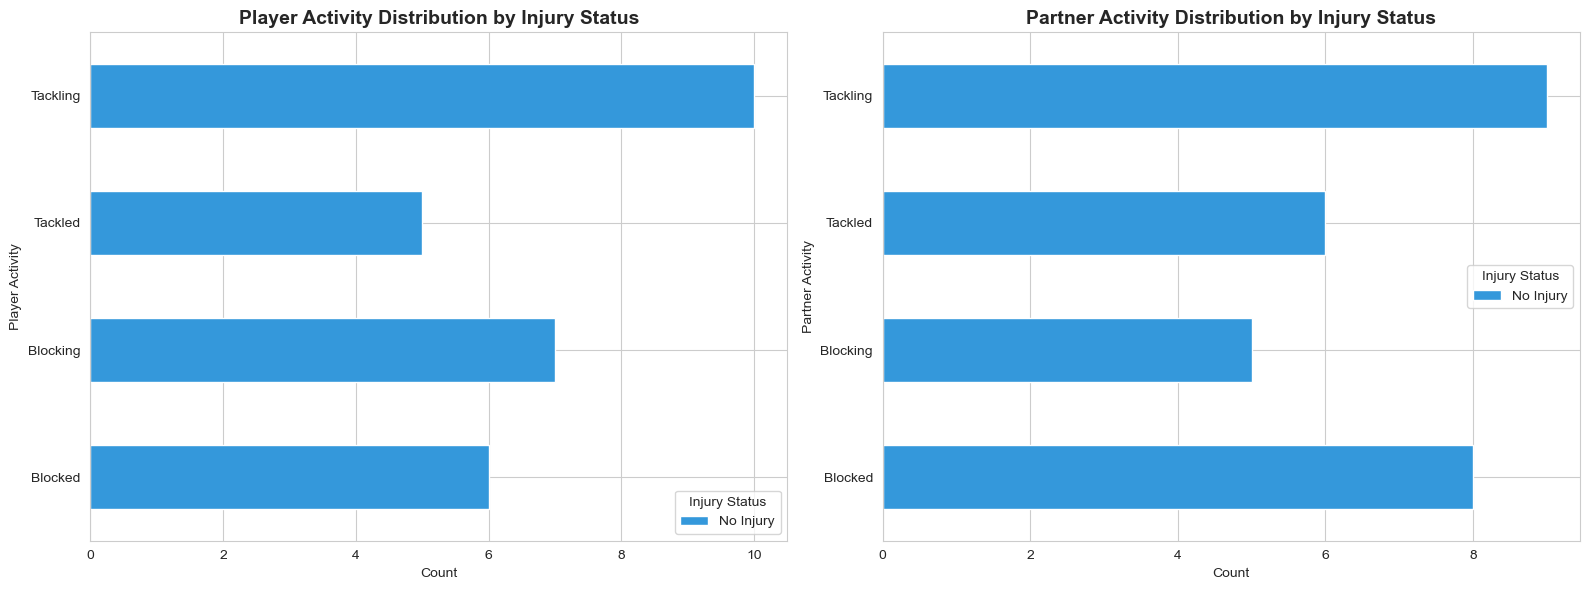

In [8]:
# 3. Player Activity Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Player Activity by Injury Status
activity_counts = injury_df.groupby(['player_activity', 'is_injury']).size().unstack(fill_value=0)
activity_counts.plot(kind='barh', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Player Activity Distribution by Injury Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Player Activity')
axes[0].legend(['No Injury', 'Injury'], title='Injury Status')

# Partner Activity by Injury Status
partner_counts = injury_df.groupby(['partner_activity', 'is_injury']).size().unstack(fill_value=0)
partner_counts.plot(kind='barh', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Partner Activity Distribution by Injury Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Partner Activity')
axes[1].legend(['No Injury', 'Injury'], title='Injury Status')

plt.tight_layout()
plt.savefig('player_activity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

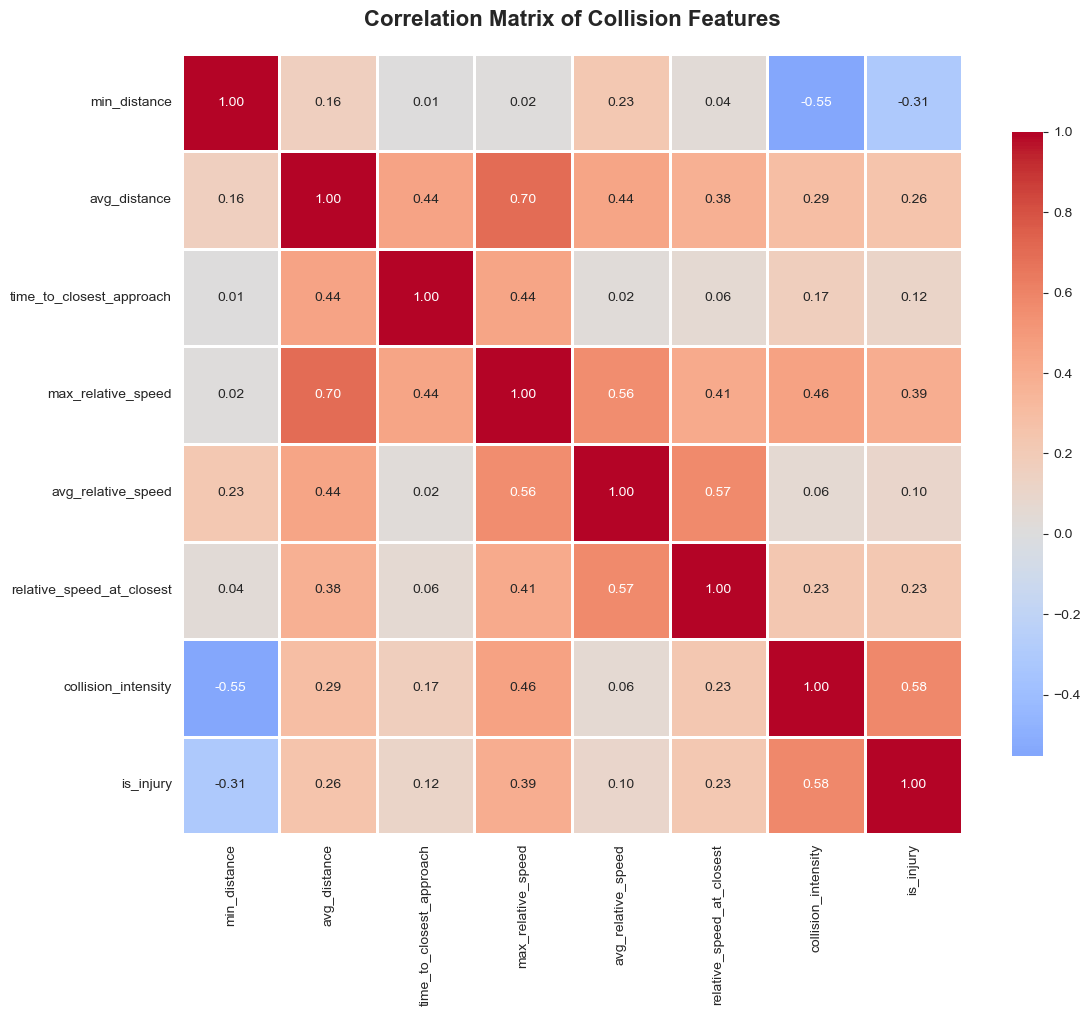

In [9]:
# 4. Correlation Heatmap for Key Features
# Select numerical features related to collision dynamics
feature_cols = ['min_distance', 'avg_distance', 'time_to_closest_approach', 
                'max_relative_speed', 'avg_relative_speed', 'relative_speed_at_closest',
                'collision_intensity', 'is_injury']

# Create correlation matrix
corr_matrix = injury_df[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Collision Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/4k/nl2zz_ln4d55dcscl_vvjglh0000gn/T/ipykernel_69420/4288938318.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=injury_df, x='is_injury', y='collision_intensity', ax=axes[0, 0],
/var/folders/4k/nl2zz_ln4d55dcscl_vvjglh0000gn/T/ipykernel_69420/4288938318.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['No Injury', 'Injury'])
/var/folders/4k/nl2zz_ln4d55dcscl_vvjglh0000gn/T/ipykernel_69420/4288938318.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=injury_df, x='is_injury', y='relative_speed_at_closest', ax=axes[0, 1],
/var/folders/4k/nl2zz_ln4d55d

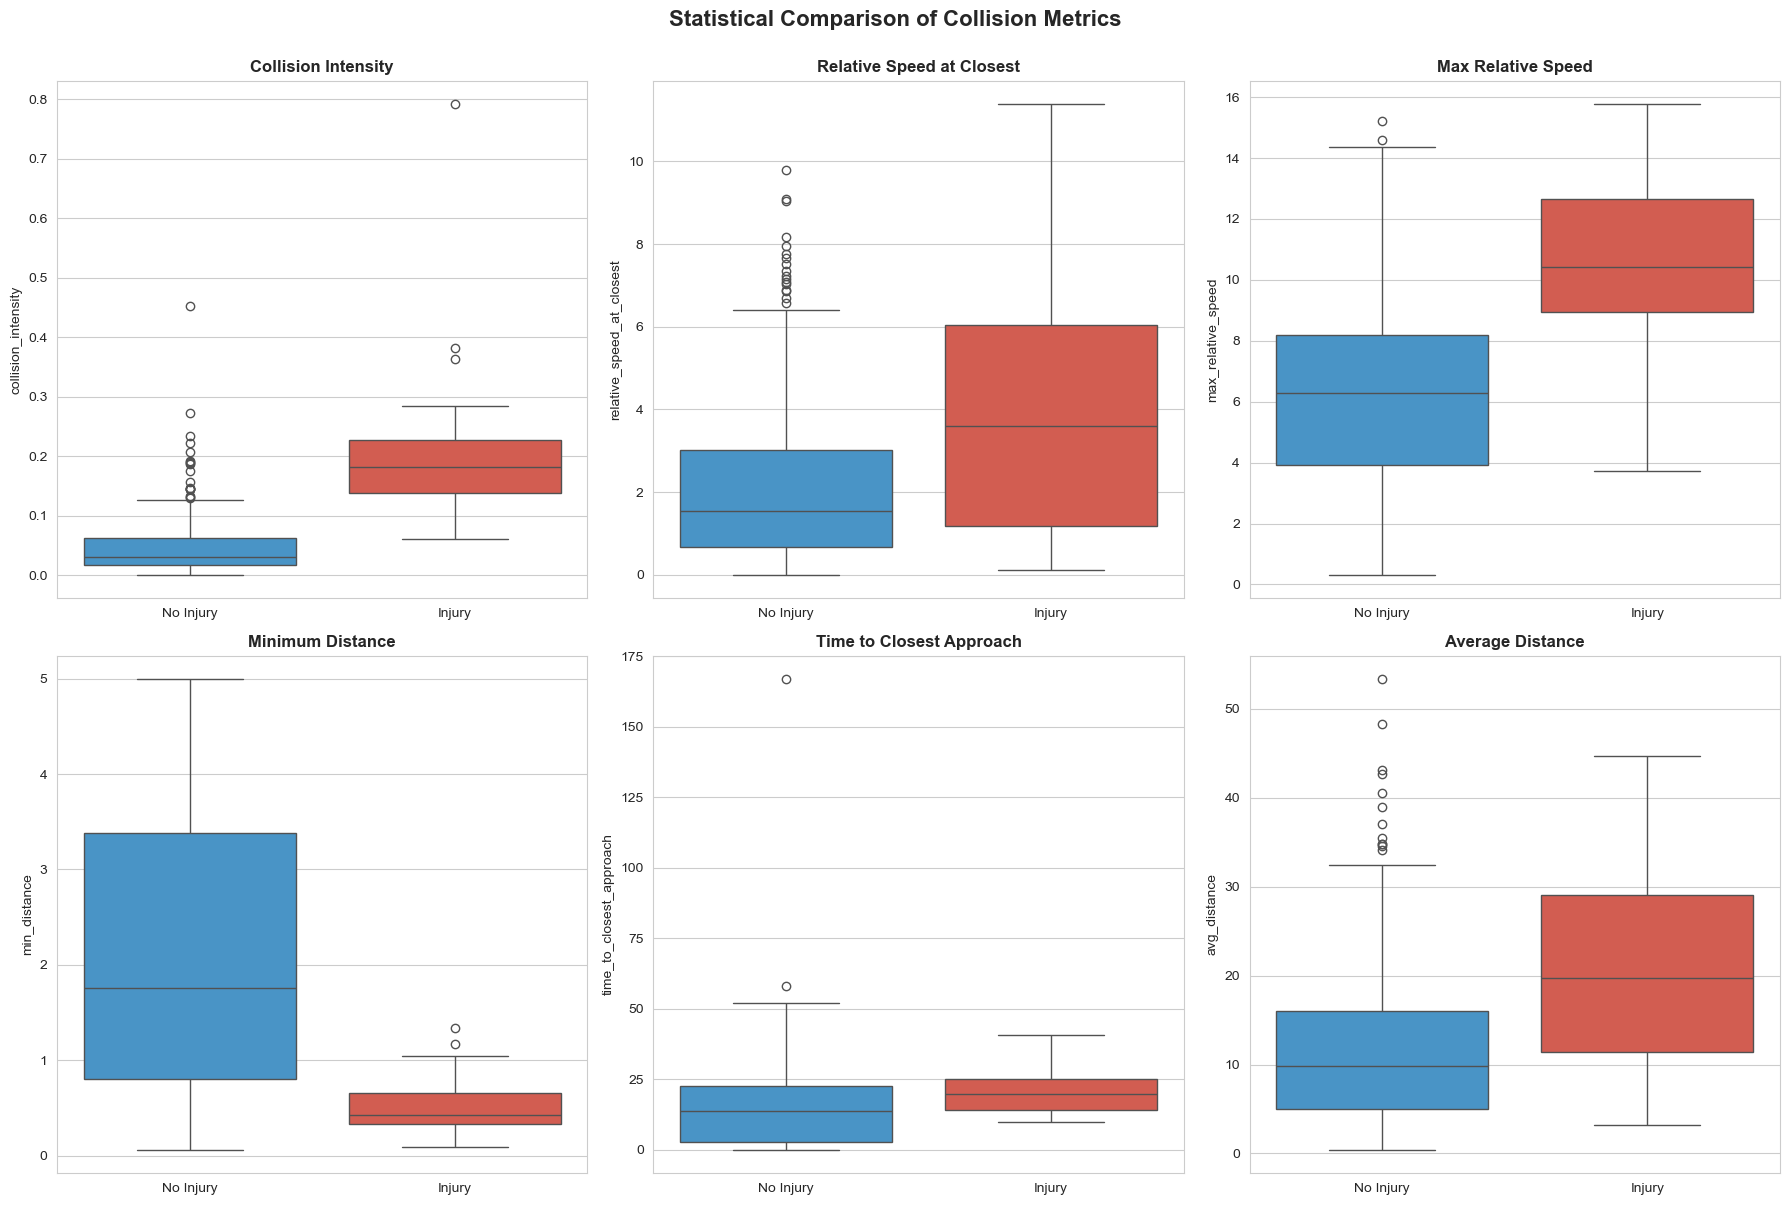

In [10]:
# 5. Box Plots for Statistical Comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Collision Intensity
sns.boxplot(data=injury_df, x='is_injury', y='collision_intensity', ax=axes[0, 0],
            palette=['#3498db', '#e74c3c'])
axes[0, 0].set_title('Collision Intensity', fontsize=12, fontweight='bold')
axes[0, 0].set_xticklabels(['No Injury', 'Injury'])
axes[0, 0].set_xlabel('')

# Relative Speed
sns.boxplot(data=injury_df, x='is_injury', y='relative_speed_at_closest', ax=axes[0, 1],
            palette=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Relative Speed at Closest', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(['No Injury', 'Injury'])
axes[0, 1].set_xlabel('')

# Max Relative Speed
sns.boxplot(data=injury_df, x='is_injury', y='max_relative_speed', ax=axes[0, 2],
            palette=['#3498db', '#e74c3c'])
axes[0, 2].set_title('Max Relative Speed', fontsize=12, fontweight='bold')
axes[0, 2].set_xticklabels(['No Injury', 'Injury'])
axes[0, 2].set_xlabel('')

# Minimum Distance
sns.boxplot(data=injury_df, x='is_injury', y='min_distance', ax=axes[1, 0],
            palette=['#3498db', '#e74c3c'])
axes[1, 0].set_title('Minimum Distance', fontsize=12, fontweight='bold')
axes[1, 0].set_xticklabels(['No Injury', 'Injury'])
axes[1, 0].set_xlabel('')

# Time to Closest Approach
sns.boxplot(data=injury_df, x='is_injury', y='time_to_closest_approach', ax=axes[1, 1],
            palette=['#3498db', '#e74c3c'])
axes[1, 1].set_title('Time to Closest Approach', fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(['No Injury', 'Injury'])
axes[1, 1].set_xlabel('')

# Average Distance
sns.boxplot(data=injury_df, x='is_injury', y='avg_distance', ax=axes[1, 2],
            palette=['#3498db', '#e74c3c'])
axes[1, 2].set_title('Average Distance', fontsize=12, fontweight='bold')
axes[1, 2].set_xticklabels(['No Injury', 'Injury'])
axes[1, 2].set_xlabel('')

plt.suptitle('Statistical Comparison of Collision Metrics', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('collision_metrics_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# 6. Summary Statistics Table
summary_stats = injury_df.groupby('is_injury')[['collision_intensity', 'relative_speed_at_closest', 
                                                  'max_relative_speed', 'min_distance', 
                                                  'time_to_closest_approach', 'avg_distance']].agg(['mean', 'std', 'median'])

print("Summary Statistics by Injury Status")
print("="*80)
print(summary_stats.round(3))

Summary Statistics by Injury Status
          collision_intensity               relative_speed_at_closest         \
                         mean    std median                      mean    std   
is_injury                                                                      
0                       0.049  0.051  0.030                     2.180  2.049   
1                       0.206  0.138  0.181                     3.891  2.868   

                 max_relative_speed                min_distance                \
          median               mean    std  median         mean    std median   
is_injury                                                                       
0          1.552              6.181  2.921   6.283        2.121  1.487  1.756   
1          3.593             10.488  2.979  10.420        0.530  0.295  0.430   

          time_to_closest_approach                avg_distance                  
                              mean     std median         mean     std  medi

In [ ]:
# PUBLICATION-QUALITY EDA FIGURE FOR TECHNICAL REPORT
# Set professional style
sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

# Create figure with custom layout
fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.4, top=0.94, bottom=0.06)

# Define color palette
injury_color = '#e74c3c'
no_injury_color = '#3498db'
colors = [no_injury_color, injury_color]

# Row 1: Dataset Overview
# 1. Class Distribution (Pie)
ax1 = fig.add_subplot(gs[0, 0])
injury_counts = injury_df['is_injury'].value_counts()
wedges, texts, autotexts = ax1.pie(injury_counts.values, labels=['No Injury', 'Injury'], 
                                      autopct='%1.1f%%', colors=colors, startangle=90,
                                      textprops={'fontsize': 11, 'weight': 'bold'})
ax1.set_title('(A) Dataset Composition', fontsize=13, weight='bold', pad=10)

# 2. Impact Type Distribution
ax2 = fig.add_subplot(gs[0, 1:3])
impact_crosstab = pd.crosstab(injury_df['impact_type'], injury_df['is_injury'])
impact_crosstab.plot(kind='bar', ax=ax2, color=colors, width=0.7, edgecolor='white', linewidth=1.5)
ax2.set_title('(B) Impact Type Distribution', fontsize=13, weight='bold', pad=10)
ax2.set_xlabel('Impact Type', fontsize=11, weight='bold')
ax2.set_ylabel('Count', fontsize=11, weight='bold')
ax2.legend(['No Injury', 'Injury'], frameon=True, fancybox=True, shadow=True, fontsize=10)
ax2.tick_params(axis='x', rotation=35, labelsize=10)
sns.despine(ax=ax2)

# 3. Collision Intensity (Most Important Feature)
ax3 = fig.add_subplot(gs[0, 3])
sns.violinplot(data=injury_df, x='is_injury', y='collision_intensity', ax=ax3,
               palette=colors, inner='box', cut=0)
ax3.set_title('(C) Collision Intensity', fontsize=13, weight='bold', pad=10)
ax3.set_xticklabels(['No Injury', 'Injury'], fontsize=10)
ax3.set_xlabel('')
ax3.set_ylabel('Intensity', fontsize=11, weight='bold')
sns.despine(ax=ax3)

# Row 2: Key Collision Dynamics (Histograms with KDE)
# 4. Collision Intensity Distribution
ax4 = fig.add_subplot(gs[1, 0])
sns.histplot(data=injury_df, x='collision_intensity', hue='is_injury', 
             palette=colors, alpha=0.6, bins=30, kde=True, ax=ax4, legend=True)
ax4.set_title('(D) Collision Intensity', fontsize=13, weight='bold', pad=10)
ax4.set_xlabel('Intensity', fontsize=11, weight='bold')
ax4.set_ylabel('Frequency', fontsize=11, weight='bold')
ax4.legend(['No Injury', 'Injury'], frameon=True, fontsize=9)
sns.despine(ax=ax4)

# 5. Relative Speed at Collision
ax5 = fig.add_subplot(gs[1, 1])
sns.histplot(data=injury_df, x='relative_speed_at_closest', hue='is_injury',
             palette=colors, alpha=0.6, bins=30, kde=True, ax=ax5, legend=True)
ax5.set_title('(E) Relative Speed', fontsize=13, weight='bold', pad=10)
ax5.set_xlabel('Speed (yards/s)', fontsize=11, weight='bold')
ax5.set_ylabel('Frequency', fontsize=11, weight='bold')
ax5.legend(['No Injury', 'Injury'], frameon=True, fontsize=9)
sns.despine(ax=ax5)

# 6. Minimum Distance
ax6 = fig.add_subplot(gs[1, 2])
sns.histplot(data=injury_df, x='min_distance', hue='is_injury',
             palette=colors, alpha=0.6, bins=30, kde=True, ax=ax6, legend=True)
ax6.set_title('(F) Minimum Distance', fontsize=13, weight='bold', pad=10)
ax6.set_xlabel('Distance (yards)', fontsize=11, weight='bold')
ax6.set_ylabel('Frequency', fontsize=11, weight='bold')
ax6.legend(['No Injury', 'Injury'], frameon=True, fontsize=9)
sns.despine(ax=ax6)

# 7. Collision Angle
ax7 = fig.add_subplot(gs[1, 3])
injury_df['abs_collision_angle'] = np.abs(injury_df['collision_angle'])
sns.histplot(data=injury_df, x='abs_collision_angle', hue='is_injury',
             palette=colors, alpha=0.6, bins=30, kde=True, ax=ax7, legend=True)
ax7.set_title('(G) Collision Angle', fontsize=13, weight='bold', pad=10)
ax7.set_xlabel('Angle (degrees)', fontsize=11, weight='bold')
ax7.set_ylabel('Frequency', fontsize=11, weight='bold')
ax7.legend(['No Injury', 'Injury'], frameon=True, fontsize=9)
sns.despine(ax=ax7)

# Row 3: Statistical Comparison (Box Plots)
metrics = [
    ('collision_intensity', 'Collision Intensity'),
    ('relative_speed_at_closest', 'Relative Speed\n(yards/s)'),
    ('min_distance', 'Min Distance\n(yards)'),
    ('time_to_closest_approach', 'Time to Closest\n(frames)')
]

for idx, (metric, label) in enumerate(metrics):
    ax = fig.add_subplot(gs[2, idx])
    sns.boxplot(data=injury_df, x='is_injury', y=metric, ax=ax,
                palette=colors, width=0.6, linewidth=2,
                flierprops=dict(marker='o', markersize=4, alpha=0.5))
    ax.set_title(f'({chr(72+idx)}) {label}', fontsize=13, weight='bold', pad=10)
    ax.set_xticklabels(['No Injury', 'Injury'], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax)

# Overall title
fig.suptitle('Exploratory Data Analysis: NFL Punt Play Collision Dataset', 
             fontsize=17, weight='bold')

plt.savefig('eda_comprehensive_figure.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('eda_comprehensive_figure.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Publication-quality EDA figure saved as PNG and PDF")